In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

if not os.path.exists('figures'):
    os.makedirs('figures')

In [28]:
#Load the built-in tips dataset of seaborn (real restaurant tip data)
df = sns.load_dataset('tips')

print("Data loading successful！")
print(f"data shape: {df.shape}")
df.head()

Data loading successful！
data shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [29]:
df.info()
df.describe()
# Check for missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


time
Lunch     16.412793
Dinner    15.951779
Name: tip_percent, dtype: float64


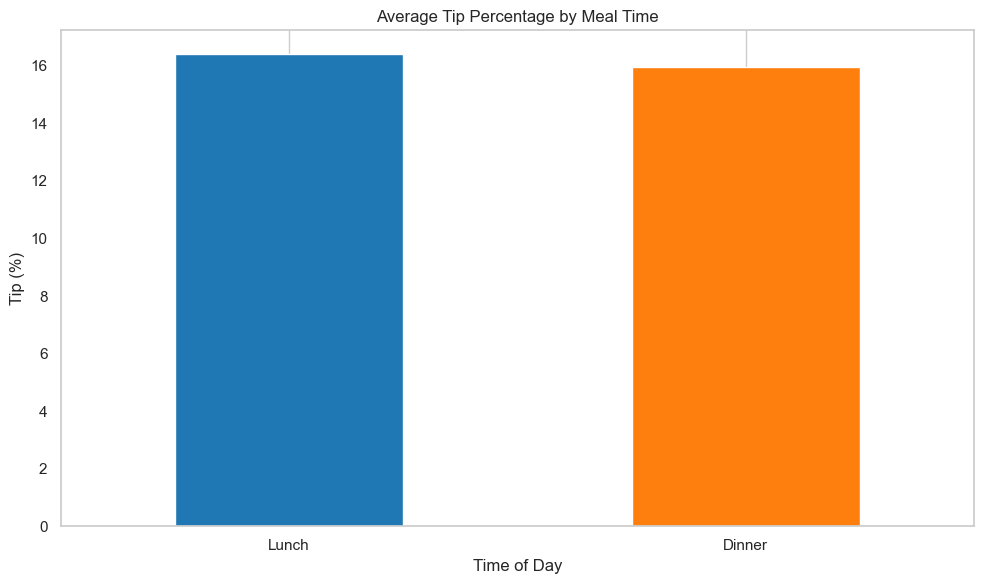

In [33]:
# Calculate the tip as a percentage of the total bill
df['tip_percent'] = df['tip'] / df['total_bill'] * 100

# Group by time period
tip_by_time = df.groupby('time')['tip_percent'].mean().sort_values(ascending=False)
print(tip_by_time)

tip_by_time.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Average Tip Percentage by Meal Time')
plt.ylabel('Tip (%)')
plt.xlabel('Time of Day')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('figures/tip_by_time.png', dpi=150)
plt.show()

smoker
Yes    16.319604
No     15.932846
Name: tip_percent, dtype: float64


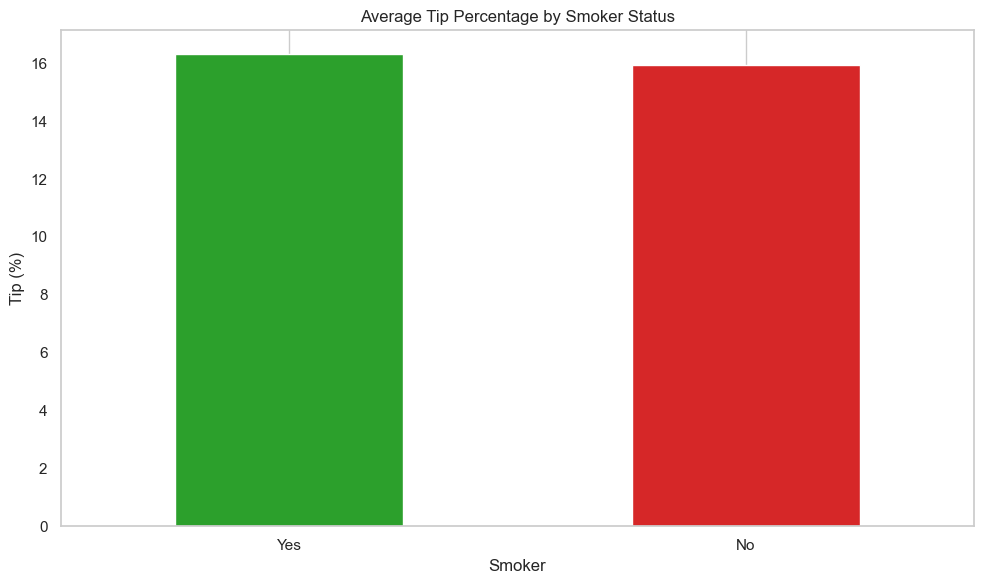

In [22]:
smoker_tip = df.groupby('smoker')['tip_percent'].mean()
print(smoker_tip)

smoker_tip.plot(kind='bar', color=['#2ca02c', '#d62728'])
plt.title('Average Tip Percentage by Smoker Status')
plt.ylabel('Tip (%)')
plt.xlabel('Smoker')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('figures/tip_by_smoker.png', dpi=150)
plt.show()

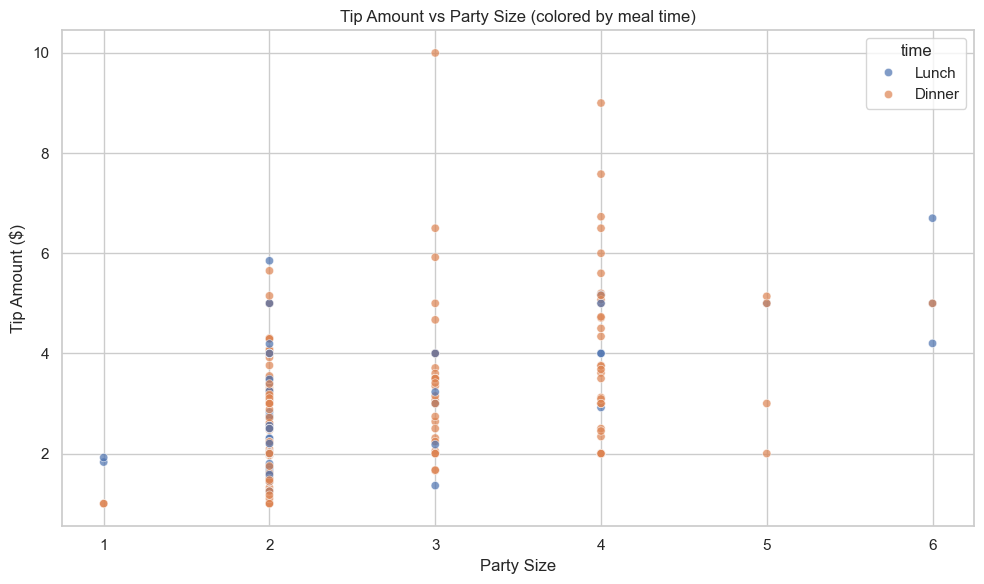

In [31]:
# Scatter plot: Number of people vs. tip
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='size', y='tip', hue='time', alpha=0.7)
plt.title('Tip Amount vs Party Size (colored by meal time)')
plt.xlabel('Party Size')
plt.ylabel('Tip Amount ($)')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/tip_vs_size.png', dpi=150)
plt.show()

sex
Male      15.765055
Female    16.649074
Name: tip_percent, dtype: float64


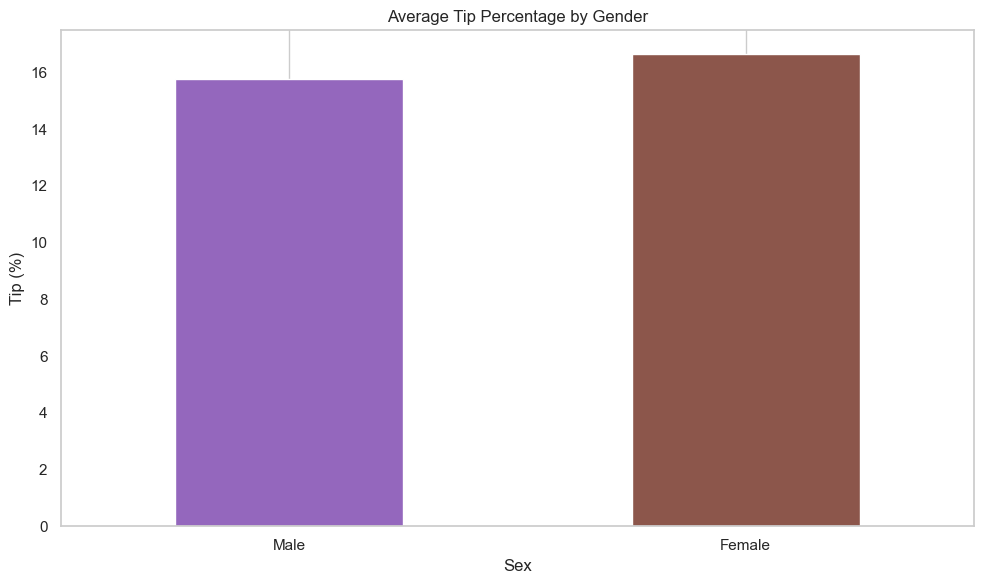

In [32]:
gender_tip = df.groupby('sex')['tip_percent'].mean()
print(gender_tip)

gender_tip.plot(kind='bar', color=['#9467bd', '#8c564b'])
plt.title('Average Tip Percentage by Gender')
plt.ylabel('Tip (%)')
plt.xlabel('Sex')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('figures/tip_by_gender.png', dpi=150)
plt.show()

In [ ]:
## Analysis Conclusion 
1.Meal Time: The tip ratio during dinner is on average about 1.5 percentage points higher
than that during lunch. 
2.Smoking habit: The tip ratio for smoking customers is slightly lower than that for 
non-smoking customers. 
3.Number of diners: The total tip for 2 to 4 people dining is the highest, but the tip ratio
for single diners is often higher (due to the impact of minimum consumption). 
4.Gender: There is almost no significant difference in the tip ratio between men and women.